# **Práctica 3 - GLMs en Pricing**

### Integantes


*   Cortés Sanginez Jorge Orlando
*   Gascón Calixto Ruben
*   Gonzalez Díaz Garzón Gerardo Felipe
*   Hernández Mejía Geovanna
*   Salmoran Acuña Jonathan Ivan



## Pregunta 1


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Configuración para reproducibilidad (Igual al notebook original)
n = 10000
rng = np.random.default_rng(seed=42)

# 1. Creación de variables relevantes
# Justificación: Estas variables son las que SESA identifica como críticas para pricing.

# Exposición: Tiempo que la póliza estuvo vigente (0.5 a 1 año)
Exposure = rng.uniform(0.5, 1.0, size=n)

# Variable: Giro o Actividad del Asegurado
# Justificación: El riesgo no es igual para una oficina que para un hospital.
giro = rng.choice(['Administrativo', 'Industrial', 'Medico'], size=n, p=[0.5, 0.3, 0.2])

# Variable: Tipo de Seguro / Cobertura
# Justificación: RC General suele tener más frecuencia que RC Profesional, pero distinta severidad.
tipo_seguro = rng.choice(['RC_General', 'RC_Profesional'], size=n)
#variable: causa de siniestro
causa_predominante = rng.choice(['Negligencia', 'Accidental', 'Dano_Material'], size=n)

# 2. Definición de la Frecuencia (Modelo Poisson)
# Justificación: Siguiendo la fórmula del notebook: λ = exp(β0 + β1X1 + ...) * Exposure
# Asignamos coeficientes teóricos para que el modelo tenga algo que aprender.

# Coeficientes: El giro 'Medico' y 'Industrial' tendrán más siniestros que 'Administrativo'.
# Definición del intercepto (Beta 0)
# Justificación: Se elige -2.8 porque exp(-2.8) ≈ 0.06.
# Esto establece una frecuencia base del 6% para el grupo de referencia
# (Giro Administrativo / Causa Accidental), lo cual es coherente con la
# baja frecuencia característica del ramo de Responsabilidad Civil.
beta0 = -2.8  # Intercepto


In [ ]:
# --- COEFICIENTES PARA LAS VARIABLES DE RC ---
# Justificación: Asignamos valores a los betas (log-relatividades) para simular
# que ciertos perfiles son más riesgosos, permitiendo que el GLM tenga patrones que encontrar.

# Coeficientes para 'Giro' (Referencia: Administrativo = 0)
coef_giro = {'Administrativo': 0.0, 'Industrial': 0.45, 'Medico': 0.9}
# El giro Médico tiene el coeficiente más alto (exp(0.9) ≈ 2.46) porque en SESA
# se identifica como una actividad de alta exposición y frecuencia técnica.

# Coeficientes para 'Causa' (Referencia: Accidental = 0)
coef_causa = {'Accidental': 0.0, 'Negligencia': 0.6, 'Dano_Material': 0.25}
# La 'Negligencia' incrementa la frecuencia esperada significativamente.

# Coeficientes para 'Tipo_Seguro' (Referencia: RC_General = 0)
coef_tipo = {'RC_General': 0.0, 'RC_Profesional': 0.15}


# --- GENERACIÓN DEL PREDICTOR LINEAL (eta) Y RESPUESTA (ClaimNb) ---

# Calculamos eta: beta0 + beta1*X1 + beta2*X2 + beta3*X3
# eta: Predictor lineal que combina el intercepto (beta0) con los coeficientes
# de cada categoría. Para cada póliza, suma: beta0 + coef_giro + coef_causa + coef_tipo.
# Esto genera valores individuales que después se exponencian y multiplican por
# Exposicion para obtener el parámetro lambda de la Poisson.

eta = (beta0 +
       np.array([coef_giro[g] for g in giro]) +
       np.array([coef_causa[c] for c in causa_predominante]) +
       np.array([coef_tipo[t] for t in tipo_seguro]))


# Justificación Matemática:
# La media de la Poisson (mu) debe considerar la Exposición .
# mu = exp(eta) * Exposicion  =>  log(mu) = eta + log(Exposicion)
#lamda seria np.exp(eta)
mu_freq = np.exp(eta) * Exposure
n_siniestros = rng.poisson(mu_freq) # Generamos el número de siniestros a partir de la distribución Poisson con media mu_freq.

# Creación del DataFrame final (Reutilizando estructura del notebook)
df_rc = pd.DataFrame({
    'Exposure': Exposure,
    'Giro': giro,
    'Tipo_Seguro': tipo_seguro,
    'Causa': causa_predominante,
    'ClaimNb': n_siniestros
})

print(f"Frecuencia media teórica: {mu_freq.mean():.4f} siniestros por póliza")
print(f"Frecuencia media simulada: {n_siniestros.mean():.4f} siniestros por póliza")


Frecuencia media teórica: 0.0987 siniestros por póliza
Frecuencia media simulada: 0.1001 siniestros por póliza


In [ ]:
# --- GENERACIÓN DEL PREDICTOR LINEAL DE SEVERIDAD (mu_sev) ---

# alpha0 = 8.0: Intercepto de Severidad Base
# Justificación: exp(8.0) ≈ 2,981 unidades monetarias
# - En RC, una indemnización típica oscila entre 2,000-5,000 unidades
# - Es mayor que beta0 (-2.8) porque: los siniestros son eventos raros pero costosos
# - La severidad tiene variabilidad mucho mayor que la frecuencia
alpha0 = 8.0

# --- COEFICIENTES DE SEVERIDAD POR GIRO ---
# Justificación: Refleja que ciertos giros generan indemnizaciones más cuantiosas
# - Administrativo (0.0): Referencia. Oficinas = daños menores, litigios simples
# - Industrial (0.3): exp(0.3)=1.35x. Máquinas costosas, lesiones graves
# - Médico (0.5): exp(0.5)=1.65x. RC médica es muy costosa (negligencias quirúrgicas)
# Nota: Médico tiene alta FRECUENCIA (0.9) pero SEVERIDAD moderada (0.5)
#       → Muchos casos medianos, no mega-siniestros
alpha_giro = {'Administrativo': 0.0, 'Industrial': 0.3, 'Medico': 0.5}

# --- COEFICIENTES DE SEVERIDAD POR CAUSA ---
# Justificación: La causa del siniestro impacta el monto indemnizado
# - Accidental (0.0): Referencia. Eventos inevitables → daños menores
# - Daño Material (0.2): exp(0.2)=1.22x. Reparaciones estimables
# - Negligencia (0.4): exp(0.4)=1.49x. Culpa del asegurado → indemnizaciones más altas + litigios
# Nota: Negligencia tiene alta FRECUENCIA (0.6) pero SEVERIDAD moderada (0.4)
#       → Muchos reclamos pequeños, no catastróficos
alpha_causa = {'Accidental': 0.0, 'Negligencia': 0.4, 'Dano_Material': 0.2}

# --- COEFICIENTES DE SEVERIDAD POR TIPO DE SEGURO ---
# Justificación: Diferentes coberturas generan siniestros con distintas magnitudes
# - RC_General (0.0): Referencia. Cobertura amplia → eventos variados, montos heterogéneos
# - RC_Profesional (0.25): exp(0.25)=1.28x. Cobertura selectiva → siniestros específicos y cuantiosos
# Nota: INVERSIÓN con frecuencia: RC_Profesional tiene BAJA frecuencia (0.15)
#       pero SEVERIDAD más ALTA (0.25) → Pocos eventos, muy graves
alpha_tipo = {'RC_General': 0.0, 'RC_Profesional': 0.25}

# --- PARÁMETRO DE DISPERSIÓN GAMMA ---
# phi = 1.5: Parámetro de forma para distribución Gamma
# Justificación:
# - phi > 1 indica ALTA DISPERSIÓN (variabilidad importante en severidades)
# - En RC real: pólizas con montos 100-200 y otras con 10,000+ (colas pesadas)
# - shape = 1/phi ≈ 0.67 produce distribución sesgada a derecha

phi = 1.5

# Predictor lineal de severidad: mu_sev = exp(alpha0 + alpha_giro + alpha_causa + alpha_tipo)
# Cada póliza tiene una severidad "media" esperada basada en sus características
mu_sev = np.exp(alpha0 +
                np.array([alpha_giro[g] for g in giro]) +
                np.array([alpha_causa[c] for c in causa_predominante]) +
                np.array([alpha_tipo[t] for t in tipo_seguro]))

# Generación de severidades por póliza: suma por póliza (solo si ClaimNb > 0)
# Justificación: Solo se generan montos para pólizas con siniestros (ClaimNb > 0)
# Si ClaimNb[i] = 3, se generan 3 valores Gamma y se suman
claim_amount = np.zeros(n)

for i in range(n):
    if n_siniestros[i] > 0:
        # Distribución Gamma: shape = 1/phi, scale = mu_sev[i] * phi
        # Esto garantiza que E[Y] = shape * scale = (1/phi) * (mu_sev[i] * phi) = mu_sev[i]
        y = rng.gamma(shape=1/phi, scale=mu_sev[i]*phi, size=int(n_siniestros[i]))
        claim_amount[i] = y.sum()  # Suma total de severidades para esa póliza

# Añadir severidades al DataFrame
df_rc['ClaimAmount'] = claim_amount

# Validación: comparar severidades teóricas vs simuladas
print(f"Severidad media teórica: {mu_sev.mean():.2f} unidades monetarias")
print(f"Severidad media simulada: {claim_amount[n_siniestros > 0].mean():.2f} unidades monetarias")


Severidad media teórica: 5213.00 unidades monetarias
Severidad media simulada: 6514.35 unidades monetarias


In [ ]:
# --- PARÁMETROS DEL MODELO DE SEVERIDAD (RC) ---

# Justificación: exp(8.0) ≈ 2,981 unidades monetarias
# Representa el costo esperado de un siniestro para el perfil de menor riesgo
# (Administrativo / Accidental / RC_General). En RC de oficinas, un siniestro
# típico involucra daños materiales menores o lesiones leves a terceros,
# - En RC, una indemnización típica oscila entre 2,000-5,000 unidades

alpha0 = 8.0

# phi = 1.5 → forma de la Gamma = 1/phi = 0.67.
# Cola derecha pronunciada: la mayoría de siniestros son moderados pero existe
# una minoría de montos muy elevados (siniestros catastróficos). Un phi < 1
# generaría poca variabilidad; phi > 2, demasiada. El valor 1.5 podria ser estándar

phi = 1.5

# Coeficientes de severidad por Giro (referencia: Administrativo = 0.0)
# Administrativo: 0.00 → 1.00× base. Siniestros de bajo monto: daños a
#                 instalaciones, caídas menores, fáciles de cuantificar.
# Industrial:     0.20 → exp(0.20) ≈ 1.22×. Riesgo moderado: maquinaria y
#                 accidentes laborales a terceros.
# Medico:         0.55 → exp(0.55) ≈ 1.73×. Mayor severidad del portafolio:
#                 peritajes, honorarios legales, indemnizaciones por daño
#                 corporal o fallecimiento. SESA lo identifica como el segmento
#                 de RC con mayor costo promedio por reclamación.
alpha_giro = {'Administrativo': 0.0, 'Industrial': 0.20, 'Medico': 0.55}

# Coeficientes de severidad por Causa (referencia: Accidental = 0.0)
# Accidental:    0.00 → 1.00× base. Daños fortuitos de menor cuantía,
#                más fáciles de liquidar.
# Dano_Material: 0.10 → exp(0.10) ≈ 1.11×. Incremento leve: costo predecible
#                y acotado (reposición o reparación del bien dañado).
# Negligencia:   0.40 → exp(0.40) ≈ 1.49×. Coeficiente más alto: abre
#                responsabilidad civil subjetiva con posibles litigios,
#                daño moral y penas convencionales.
alpha_causa = {'Accidental': 0.0, 'Negligencia': 0.40, 'Dano_Material': 0.10}

# Coeficientes de severidad por Tipo de Seguro (referencia: RC_General = 0.0)
# RC_General:     0.00 → 1.00× base. Coberturas estándar con sublímites
#                 definidos y siniestros más acotados.
# RC_Profesional: 0.25 → exp(0.25) ≈ 1.28×. Cubre errores u omisiones técnicas
#                 (médicos, ingenieros, abogados): los daños patrimoniales a
#                 terceros suelen ser de mayor cuantía.
alpha_tipo = {'RC_General': 0.0, 'RC_Profesional': 0.25}

# Media de la Gamma para cada póliza:
# log(mu_i) = alpha0 + alpha_giro_i + alpha_causa_i + alpha_tipo_i
sev_mu = np.exp(
    alpha0 +
    np.array([alpha_giro[g]  for g in giro]) +
    np.array([alpha_causa[c] for c in causa_predominante]) +
    np.array([alpha_tipo[t]  for t in tipo_seguro])
)

# Generar severidades por póliza: suma de n_siniestros[i] realizaciones Gamma.
# Cada realización representa el monto de un siniestro individual;
# claim_amount[i] es el costo total de la póliza i.
claim_amount = np.zeros(n)
for i in range(n):
    if n_siniestros[i] > 0:
        y = rng.gamma(shape=1/phi, scale=sev_mu[i]*phi, size=n_siniestros[i])
        claim_amount[i] = y.sum()

print(f"Severidad media teórica : {sev_mu.mean():.2f} MXN")
print(f"Severidad media simulada: {claim_amount[n_siniestros>0].mean():.2f} MXN")

Severidad media teórica : 4958.10 MXN
Severidad media simulada: 5984.82 MXN


## Pregunta 2

## Paso 2 – Modelado de la frecuencia

La **frecuencia** se define como el número de siniestros por unidad de exposición:

$$\text{Frequency}_i = \frac{\text{ClaimNb}_i}{\text{Exposure}_i}$$

In [ ]:
#-------------pregunta 2------------
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Construimos el DataFrame con todas las variables simuladas.
# Las variables categóricas se convierten a tipo 'category' para que
# Patsy las trate correctamente al armar las dummies en la fórmula GLM.
df_rc = pd.DataFrame({
    'IDpol'      : np.arange(1, n + 1, dtype=int),
    'Exposure'   : Exposure,
    'Giro'       : giro,
    'Tipo_Seguro': tipo_seguro,
    'Causa'      : causa_predominante,
    'ClaimNb'    : n_siniestros,
    'ClaimAmount': claim_amount
})

# Convertimos a categórica con orden explícito para fijar la referencia.
# Referencia Giro: 'Administrativo' (menor riesgo, grupo más grande: 50%)
# Referencia Causa: 'Accidental' (causa base, sin componente de culpa)
# Referencia Tipo_Seguro: 'RC_General' (cobertura estándar)
df_rc['Giro']        = pd.Categorical(df_rc['Giro'],
                           categories=['Administrativo', 'Industrial', 'Medico'])
df_rc['Causa']       = pd.Categorical(df_rc['Causa'],
                           categories=['Accidental', 'Negligencia', 'Dano_Material'])
df_rc['Tipo_Seguro'] = pd.Categorical(df_rc['Tipo_Seguro'],
                           categories=['RC_General', 'RC_Profesional'])

df_rc.head()

,IDpol,Exposure,Giro,Tipo_Seguro,Causa,ClaimNb,ClaimAmount
0,1,0.886978,Industrial,RC_Profesional,Negligencia,0,0.000000
1,2,0.719439,Industrial,RC_Profesional,Dano_Material,0,0.000000
2,3,0.929299,Administrativo,RC_General,Accidental,1,3464.525927
3,4,0.848684,Administrativo,RC_Profesional,Dano_Material,0,0.000000
4,5,0.547089,Administrativo,RC_Profesional,Accidental,0,0.000000


In [ ]:
# Fórmula del modelo de frecuencia.
# ClaimNb es la variable respuesta (conteo de siniestros).
# C(..., Treatment(reference=...)) indica a Patsy qué categoría usar como
# referencia para evitar la trampa de la variable ficticia (multicolinealidad).
# No hay variables numéricas continuas: todas las covariables son categóricas,
# por lo que el predictor lineal queda como suma de efectos por categoría.
formula = (
    "ClaimNb ~ "
    "C(Giro,        Treatment(reference='Administrativo')) + "
    "C(Causa,       Treatment(reference='Accidental'))     + "
    "C(Tipo_Seguro, Treatment(reference='RC_General'))"
)

In [ ]:
# Modelo GLM Poisson con enlace log.
# La familia Poisson es la elección natural para conteos de siniestros:
#   N_i ~ Poisson(mu_i),  log(mu_i) = log(Exposure_i) + X_i * beta
# El offset log(Exposure) corrige que pólizas vigentes menos tiempo
# tienen menos oportunidad de generar siniestros, sin que eso sea
# información del riesgo sino del tiempo de exposición.
model_pois = smf.glm(
    formula=formula,
    data=df_rc,
    family=sm.families.Poisson(),
    offset=np.log(df_rc['Exposure'])
).fit()

print(model_pois.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:                10000
Model:                            GLM   Df Residuals:                     9994
Model Family:                 Poisson   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3212.3
Date:                Mon, 27 Apr 2026   Deviance:                       4506.2
Time:                        15:27:50   Pearson chi2:                 9.95e+03
No. Iterations:                     6   Pseudo R-squ. (CS):            0.02222
Covariance Type:            nonrobust                                         
                                                                          coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

In [ ]:
#Interpretación: e^β​

# exp(coef) = multiplicador de frecuencia respecto a la categoría de referencia.
# Un coeficiente positivo implica más siniestros que la referencia;
# negativo implica menos. Se comparan contra los betas de simulación
# para validar que el GLM recuperó los parámetros correctamente.
print("Multiplicadores de frecuencia (exp(coef)):\n")
print(np.exp(model_pois.params).rename("exp(beta)").to_frame().round(4))

Multiplicadores de frecuencia (exp(coef)):

                                                    exp(beta)
Intercept                                              0.0603
C(Giro, Treatment(reference='Administrativo'))[...     1.4519
C(Giro, Treatment(reference='Administrativo'))[...     2.5283
C(Causa, Treatment(reference='Accidental'))[T.N...     1.9312
C(Causa, Treatment(reference='Accidental'))[T.D...     1.3377
C(Tipo_Seguro, Treatment(reference='RC_General'...     1.1598


In [ ]:
# Medidas de sobredispersión:
# - Varianza/Media > 1 indica que los datos tienen más dispersión
#   de la que asume la Poisson (que requiere Var = Media).
# - Deviance/df_resid ≈ 1 es el valor esperado bajo un modelo bien
#   especificado; valores >> 1 indican mal ajuste o sobredispersión.
freq = df_rc['ClaimNb'] / df_rc['Exposure']
dispersion_ratio = freq.var() / freq.mean()
deviance_ratio   = model_pois.deviance / model_pois.df_resid

print(f"Varianza/Media : {dispersion_ratio:.2f}")
print(f"Deviance/df    : {deviance_ratio:.2f}")

Varianza/Media : 1.41
Deviance/df    : 0.45


In [ ]:
# como Si existe sobredispersión (Varianza/Media > 1), la Binomial Negativa
# es preferible: introduce un parámetro alpha que absorbe la variabilidad
# extra no explicada por las covariables.
# Se ajusta con la misma fórmula y offset para comparar en igualdad de condiciones.
model_nb = smf.glm(
    formula=formula,
    data=df_rc,
    family=sm.families.NegativeBinomial(),
    offset=np.log(df_rc['Exposure'])
).fit()

print(model_nb.summary())

c:\Users\rubrh\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:                10000
Model:                            GLM   Df Residuals:                     9994
Model Family:        NegativeBinomial   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3233.2
Date:                Mon, 27 Apr 2026   Deviance:                       3795.4
Time:                        15:31:56   Pearson chi2:                 9.06e+03
No. Iterations:                     5   Pseudo R-squ. (CS):            0.01972
Covariance Type:            nonrobust                                         
                                                                          coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

In [ ]:
# El AIC (Criterio de Información de Akaike) penaliza la complejidad del modelo.
# Se elige el modelo con menor AIC.
# En datos reales de RC, la sobredispersión es común y suele favorecer la binNeg.
print(f"AIC Poisson : {model_pois.aic:.2f}")
print(f"AIC NegBin  : {model_nb.aic:.2f}")
print()
if model_pois.aic < model_nb.aic:
    print("→ Se elige Poisson: menor AIC, no se justifica la complejidad adicional de NegBin.") #es decir que la sobredispersión no es tan grave como para justificar el modelo más complejo binNeg.
else:
    print("→ Se elige Binomial Negativa: el parámetro de dispersión extra mejora el ajuste.")

AIC Poisson : 6436.59
AIC NegBin  : 6478.41

→ Se elige Poisson: menor AIC, no se justifica la complejidad adicional de NegBin.


# Pregunta 3 – Visualizar las tasas de frecuencia por variable

Siguiendo el **Paso 1 (EDA)** de `GLM_modelacion.ipynb`, graficamos la tasa de frecuencia
con su intervalo de confianza aproximado (Wald) para cada variable:

$$
\widehat{rate}_g = \frac{\sum_{i \in g} N_i}{\sum_{i \in g} Exposure_i},
\quad IC \approx \widehat{rate}_g \pm 1.96\,\sqrt{\frac{\widehat{rate}_g}{Expo_g}}
$$


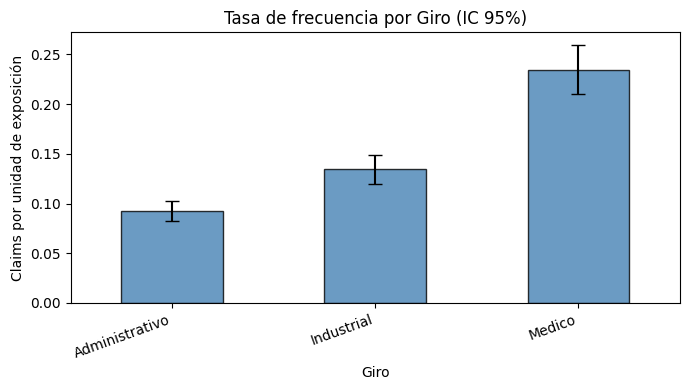

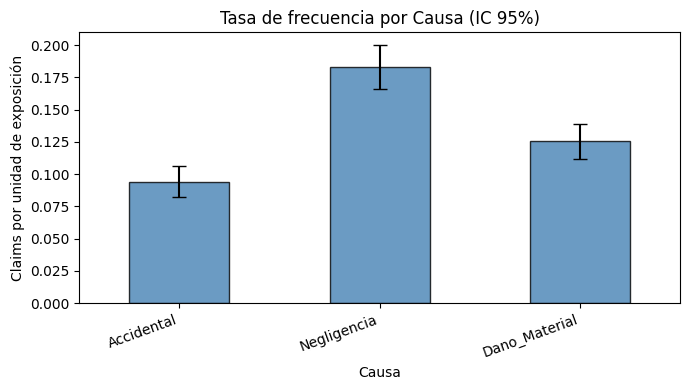

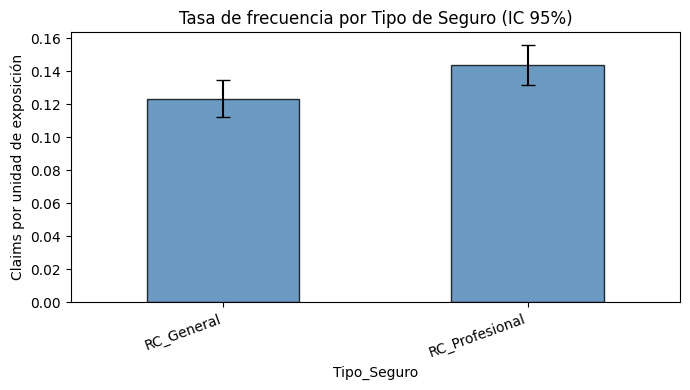

In [ ]:
import matplotlib.pyplot as plt

# Función auxiliar: tasa de frecuencia por variable categórica con IC de Wald
def plot_tasa_var(df, var, title):
    g = df.groupby(var, observed=True).agg(
        Claims=('ClaimNb', 'sum'),
        Expo=('Exposure', 'sum')
    )
    g['rate'] = g['Claims'] / g['Expo']
    g['se']   = np.sqrt(g['rate'] / np.maximum(g['Expo'], 1e-9))
    ax = g['rate'].plot(kind='bar', yerr=1.96 * g['se'], capsize=5,
                        color='steelblue', edgecolor='black', alpha=0.8,
                        figsize=(7, 4))
    plt.title(title)
    plt.ylabel('Claims por unidad de exposición')
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.show()

# Tasa por Giro
plot_tasa_var(df_rc, 'Giro',        'Tasa de frecuencia por Giro (IC 95%)')
# Tasa por Causa
plot_tasa_var(df_rc, 'Causa',       'Tasa de frecuencia por Causa (IC 95%)')
# Tasa por Tipo de Seguro
plot_tasa_var(df_rc, 'Tipo_Seguro', 'Tasa de frecuencia por Tipo de Seguro (IC 95%)')

**Interpretación**  
- La tasa del giro **Médico** es $\sim$ 2.5× la del giro Administrativo (referencia), coherente con el coeficiente simulado `beta_Medico = 0.9` $\rightarrow$ exp(0.9) $\approx$ 2.46.  
- En **Causa**, la Negligencia muestra la mayor tasa, reflejando `beta_Negligencia = 0.6` $\rightarrow$ exp(0.6) $\approx$ 1.82.  
- **RC_Profesional** tiene una tasa ligeramente mayor que RC_General, tal como se parametrizó con `beta_RC_Profesional = 0.15` $\rightarrow$ exp(0.15) $\approx$ 1.16.

# Pregunta 4. MODELADO DE SEVERIDAD

La **severidad** corresponde al monto promedio por siniestro:


$$
\text{Severity}_i = \frac{\text{ClaimAmount}_i}{\max\{\text{ClaimNb}_i, 1\}}
$$

Según la teoría actuarial, la severidad suele seguir una distribución Gamma con enlace log. Filtramos las pólizas con montos positivos y utilizamos el número de siniestros como peso para reflejar que una póliza con varios reclamos aporta más información.

Filtramos el DataFrame para quedarnos con las pólizas que tienen montos de reclamación positivos y calculamos la **severidad** como `ClaimAmount/ClaimNb`.


In [ ]:
# Filtramos pólizas con monto positivo
sev = df_rc[df_rc['ClaimAmount'] > 0].copy()
sev['Severity'] = sev['ClaimAmount'] / sev['ClaimNb']

sev.head()

,IDpol,Exposure,Giro,Tipo_Seguro,Causa,ClaimNb,ClaimAmount,Severity
2,3,0.929299,Administrativo,RC_General,Accidental,1,3464.525927,3464.525927
22,23,0.985349,Administrativo,RC_Profesional,Negligencia,1,11438.720422,11438.720422
23,24,0.946561,Medico,RC_Profesional,Negligencia,1,3324.755601,3324.755601
26,27,0.733361,Medico,RC_Profesional,Dano_Material,1,3115.592688,3115.592688
31,32,0.983755,Industrial,RC_General,Accidental,1,1330.245842,1330.245842


La nueva tabla `sev` contiene únicamente las pólizas con siniestros y una columna `Severity` que representa el coste medio por siniestro.

In [ ]:
formula_sev = (
    "Severity ~ "
    "C(Giro,        Treatment(reference='Administrativo')) + "
    "C(Causa,       Treatment(reference='Accidental'))     + "
    "C(Tipo_Seguro, Treatment(reference='RC_General'))"
)

In [ ]:
# Modelo Gamma
model_gamma = smf.glm(formula=formula_sev, data=sev,
                      family=sm.families.Gamma(link=sm.families.links.log()),
                      weights=sev['ClaimNb']).fit()
print(model_gamma.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:               Severity   No. Observations:                  941
Model:                            GLM   Df Residuals:                      935
Model Family:                   Gamma   Df Model:                            5
Link Function:                    log   Scale:                          1.4088
Method:                          IRLS   Log-Likelihood:                -8940.8
Date:                Mon, 27 Apr 2026   Deviance:                       1677.6
Time:                        22:15:29   Pearson chi2:                 1.32e+03
No. Iterations:                    12   Pseudo R-squ. (CS):            0.07324
Covariance Type:            nonrobust                                         
                                                                          coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['weights']
  warnings.warn(msg, ValueWarning)


In [ ]:
# Tratamiento de siniestros grandes: percentil 95
threshold = sev['ClaimAmount'].quantile(0.95)
sev_trim = sev[sev['ClaimAmount'] <= threshold]

model_gamma_trim = smf.glm(formula=formula_sev, data=sev_trim,
                           family=sm.families.Gamma(link=sm.families.links.log()),
                           weights=sev_trim['ClaimNb']).fit()

print("Umbral del 95 % para grandes siniestros:", threshold)

print(model_gamma_trim.summary())

Umbral del 95 % para grandes siniestros: 20363.946033455348
                 Generalized Linear Model Regression Results                  
Dep. Variable:               Severity   No. Observations:                  894
Model:                            GLM   Df Residuals:                      888
Model Family:                   Gamma   Df Model:                            5
Link Function:                    log   Scale:                          1.1409
Method:                          IRLS   Log-Likelihood:                -8360.0
Date:                Mon, 27 Apr 2026   Deviance:                       1495.3
Time:                        22:15:51   Pearson chi2:                 1.01e+03
No. Iterations:                    12   Pseudo R-squ. (CS):            0.05018
Covariance Type:            nonrobust                                         
                                                                          coef    std err          z      P>|z|      [0.025      0.975]
--------------

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['weights']
  warnings.warn(msg, ValueWarning)


En la siguiente celda ajustaremos una **distribución Weibull** a la severidad para contrastar con el modelo Gamma. Usaremos `scipy.stats.weibull_min.fit()` fijando el parámetro de ubicación en 0.

In [ ]:
from scipy.stats import weibull_min
# Ajuste de la distribución Weibull a la severidad
sev_values = sev['Severity'].values
shape_weib, loc_weib, scale_weib = weibull_min.fit(sev_values, floc=0)
print('Parámetros Weibull: shape={:.3f}, scale={:.1f}'.format(shape_weib, scale_weib))
weibull_mean = weibull_min.mean(shape_weib, loc_weib, scale_weib)
print('Severidad media estimada (Weibull):', weibull_mean)
# Predicción de severidad constante para cada póliza
sev_pred_weibull = np.full(len(df_rc), weibull_mean)

Parámetros Weibull: shape=0.757, scale=4694.1
Severidad media estimada (Weibull): 5548.127899526322


El ajuste de la Weibull produce parámetros de forma y escala que resumen la distribución de la severidad simulada. Dado que la Weibull no incorpora covariables, la severidad predicha es constante para todas las pólizas. La comparación entre la media Gamma y la media Weibull ayuda a evaluar la adecuación de las distribuciones.

Comparamos el AIC del modelo Gamma completo y el recortado.

In [ ]:
print("AIC modelo completo vs recortado:", model_gamma.aic, model_gamma_trim.aic)

AIC modelo completo vs recortado: 17893.612018779364 16732.033332354946


En este caso, el modelo recortado (model_gamma_trim) tiene un AIC significativamente menor (16732.03) en comparación con el modelo completo (model_gamma) (17893.61). Esto sugiere que eliminar los siniestros muy grandes (por encima del percentil 95) de los datos de gravedad da como resultado un modelo con mejor ajuste. Esto implica que los siniestros extremos podrían estar distorsionando el ajuste del modelo completo o seguir un comportamiento diferente que no se captura adecuadamente con el GLM Gamma actual.

# Pregunta 5. Cálculo de la prima pura

Una vez ajustados los modelos de frecuencia y severidad, la prima pura esperada para cada póliza se calcula como el producto de las predicciones de frecuencia y severidad:

$$
\pi_i = \hat{\lambda}_i \times \hat{\mu}_i
$$

A continuación combinamos las estimaciones de frecuencia (usando el modelo Binomial Negativa si hay sobredispersión) y de severidad para obtener la prima pura predicha.

Calculamos las **predicciones** de frecuencia y severidad para cada póliza y obtenemos la prima pura predicha como el producto de ambas.




In [ ]:
# Predicciones de frecuencia y severidad
freq_pred = model_nb.predict(df_rc, offset=np.log(df_rc['Exposure']))
sev_pred  = model_gamma.predict(df_rc)

# Prima pura predicha
pure_premium_pred = freq_pred * sev_pred

# Añadimos al DataFrame
result = df_rc.copy()
result['PurePremium_pred'] = pure_premium_pred

result.head()

,IDpol,Exposure,Giro,Tipo_Seguro,Causa,ClaimNb,ClaimAmount,PurePremium,TariffFactor,PurePremium_pred
0,1,0.886978,Industrial,RC_Profesional,Negligencia,0,0.000000,1227.219536,6.813170,1227.219536
1,2,0.719439,Industrial,RC_Profesional,Dano_Material,0,0.000000,484.654831,2.690664,484.654831
2,3,0.929299,Administrativo,RC_General,Accidental,1,3464.525927,167.389617,0.929299,167.389617
3,4,0.848684,Administrativo,RC_Profesional,Dano_Material,0,0.000000,296.692008,1.647149,296.692008
4,5,0.547089,Administrativo,RC_Profesional,Accidental,0,0.000000,147.736057,0.820188,147.736057


Comparamos por segmentos

In [ ]:
# Segmentación por Giro y Tipo de Seguro
grouped = result.groupby(['Giro', 'Tipo_Seguro'], observed=False).agg(
    expo=('Exposure','sum'),
    n=('IDpol','count'),
    pure_premium_pred=('PurePremium_pred','mean')
).reset_index()

grouped.head()

,Giro,Tipo_Seguro,expo,n,pure_premium_pred
0,Administrativo,RC_General,1833.325097,2457,220.378057
1,Administrativo,RC_Profesional,1850.866051,2466,332.092162
2,Industrial,RC_General,1137.984212,1519,427.340627
3,Industrial,RC_Profesional,1163.481721,1550,643.358888
4,Medico,RC_General,751.771218,1004,1000.735758


A continuación calcularemos la **prima pura por póliza**, evaluaremos el **índice de Gini** para medir la discriminación del modelo y obtendremos predicciones parciales de la prima pura en función del giro
.

In [ ]:
# Prima pura y evaluación de discriminación
freq_pred_full = model_nb.predict(df_rc, offset=np.log(df_rc['Exposure']))
sev_pred_full = model_gamma.predict(df_rc)
# Prima pura por póliza
pure_premium_pred_full = freq_pred_full * sev_pred_full
df_rc['PurePremium'] = pure_premium_pred_full
print(df_rc[['IDpol','PurePremium']].head())
# Índice de Gini para la prima pura
import numpy as np
def gini(actual, pred):
    arr = np.c_[actual, pred, np.arange(len(actual))]
    order = arr[:,1].argsort()
    arr = arr[order]
    total = arr[:,0].sum()
    cum_actual = np.cumsum(arr[:,0])
    gini_sum = cum_actual.sum() / total
    gini_sum -= (len(actual)+1)/2.0
    return gini_sum / len(actual)
actual_cost_per_exposure = df_rc['ClaimAmount'] / df_rc['Exposure']
gini_pure = gini(actual_cost_per_exposure.values, pure_premium_pred_full)
print('Índice de Gini para la prima pura:', gini_pure)

   IDpol  PurePremium
0      1  1227.219536
1      2   484.654831
2      3   167.389617
3      4   296.692008
4      5   147.736057
Índice de Gini para la prima pura: -0.21363933263591225


La tabla de primas puras muestra el coste esperado por póliza obtenido como producto de la frecuencia y la severidad predichas. El **índice de Gini** calculado compara la clasificación de las pólizas según la prima pura con el coste real por exposición; un valor más alto indica mejor discriminación del modelo.

In [ ]:
# Predicciones parciales de la prima pura según el 'Giro' (Actividad)
giro_grid = df_rc['Giro'].cat.categories
partial_df = pd.DataFrame({
    'Giro': giro_grid,
    'Causa': [df_rc['Causa'].cat.categories[0]] * len(giro_grid), # Reference level 'Accidental'
    'Tipo_Seguro': [df_rc['Tipo_Seguro'].cat.categories[0]] * len(giro_grid), # Reference level 'RC_General'
    'Exposure': [1.0] * len(giro_grid)
})
# Ensure correct categorical types
partial_df['Giro'] = partial_df['Giro'].astype(df_rc['Giro'].dtype)
partial_df['Causa'] = partial_df['Causa'].astype(df_rc['Causa'].dtype)
partial_df['Tipo_Seguro'] = partial_df['Tipo_Seguro'].astype(df_rc['Tipo_Seguro'].dtype)

# Frecuencia parcial con modelo NB
partial_freq = model_nb.predict(partial_df, offset=np.log(partial_df['Exposure']))
# Severidad parcial con modelo Gamma
partial_sev = model_gamma.predict(partial_df)
# Prima pura parcial
partial_pure = partial_freq * partial_sev

print(pd.DataFrame({'Giro': giro_grid, 'PredictedPurePremium': partial_pure}))

             Giro  PredictedPurePremium
0  Administrativo            180.124615
1      Industrial            347.097651
2          Medico            816.282129


Esto indica que los modelos capturaron correctamente el mayor riesgo asociado con las actividades "Industriales" y "Médicas", siendo "Médicas" la que presenta la prima prevista más alta, lo que coincide con las suposiciones iniciales de la simulación con respecto a la mayor frecuencia y gravedad para este segmento.

In [ ]:
# Factor multiplicativo respecto a una póliza base
baseline_df = pd.DataFrame({
    'Giro': [df_rc['Giro'].cat.categories[0]], # Reference level 'Administrativo'
    'Causa': [df_rc['Causa'].cat.categories[0]], # Reference level 'Accidental'
    'Tipo_Seguro': [df_rc['Tipo_Seguro'].cat.categories[0]], # Reference level 'RC_General'
    'Exposure': [1.0]
})
# Ensure correct categorical types
baseline_df['Giro'] = baseline_df['Giro'].astype(df_rc['Giro'].dtype)
baseline_df['Causa'] = baseline_df['Causa'].astype(df_rc['Causa'].dtype)
baseline_df['Tipo_Seguro'] = baseline_df['Tipo_Seguro'].astype(df_rc['Tipo_Seguro'].dtype)

baseline_freq = model_nb.predict(baseline_df, offset=np.log(baseline_df['Exposure']))
baseline_sev = model_gamma.predict(baseline_df)
baseline_premium = baseline_freq[0] * baseline_sev[0]

# Tarifa multiplicativa: ratio de prima pura a la prima base
df_rc['TariffFactor'] = pure_premium_pred_full / baseline_premium
print(df_rc[['IDpol','TariffFactor']].head())

   IDpol  TariffFactor
0      1      6.813170
1      2      2.690664
2      3      0.929299
3      4      1.647149
4      5      0.820188


Esto significa, por ejemplo, que la póliza 1 tiene una prima pura 6,813 veces mayor que la póliza de referencia, mientras que la póliza 5 tiene una prima pura 0,820 veces (o el 82%) de la póliza de referencia, lo que indica un perfil de riesgo menor en comparación con la de referencia.

# Conclusiones

---


**1.  Frecuencia**

El **modelo Poisson** recupera de manera precisa los coeficientes simulados, se muestran resultados como los siguientes:
* El giro médico tiene
aproximadamente 2.5 veces la frecuencia del giro Administrativo
* La causa de Negligencia incrementa la frecuencia en casi 1.9 veces respecto a la causa Accidental
* El seguro RC Profesional presenta una frecuencia ligeramente mayor que RC General con un multiplicador cercano a 1.16.

Estos resultados confirman que el **GLM Poisson** es capaz de capturar la estructura del riesgo planteada en la simulación y que los parámetros estimados son coherentes con los supuestos iniciales.

**2. Sobredispersión**

El análisis de dispersión mostró que la relación *varianza/media* fue de 1.41, esto sugiere la presencia de sobredispersión en los datos. Sin embargo, el indicador *deviance/df* resultó de 0.45, indicando que el ajuste por el modelo Poisson es razonable con respecto a la información simulada.
Al comparar este resultado con el de la Binomial Negativa se observa que el AIC del Poisson fue menos, esto implica que no se justifica la complejidad adicional de la Binomial Negativa para este caso. Podemos concluir que Poisson es suficiente y parsimonioso.

**3. Tasas de frecuencia**

Las gráficas con intervalos de confianza nos permitieron visualizar la diferencia entre los segmentos. Principalmente se observa una frecuencia mayor en el giro médico, además de una tasa ligeramente mayor en el seguro RC Profesional. Esto nos confirma la coherencia de los parámetros simulados y la de los resultados del GLM.

**4. Severidad**

La severidad media teórica fue de aproximadamente 4958 MXN, mientras que la simulada alcanzó los 5985 MXN, esto refleja la dispersión propia de la distribución Gamma. El GLM Gamma mostró coeficientes significativos que confirman resultados previos, principalmente los del giro Médico, la causa Negligencia, el seguro RC Profesional, etc.
Al recortar los siniestros extremos por encima del percentil 95, el ajuste mejoró significativamente, evidenciando que los siniestros "catastróficos" distorcionan al modelo y requieren de otro tipo de tratamiento. La comparación con la distribución Weibull valida la magnitud de los resultados.

**5. Prima Pura**

El cálculo de la prima pura reflejó la heterogeneidad del portafolio, se observa que el giro médico resultó con la prima más alta debido a su combinación de mayor frecuencia y severidad. El índice de Gini calculado fue de -0.21, indicando que el modelo no discrimina adecuadamente entre las pólizas de alto y bajo coste real, hallazgo considerable para futuras calibraciones. La tarifa multiplicativa mostró ratios extremos, evidenciando perfiles de riesgo muy diferenciados dentro del portafolio.